In [3]:
from langgraph.graph import StateGraph,START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os 

In [4]:
load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant", 
               temperature=0.3,
                max_tokens=2048,
                api_key=os.getenv("GROQ_API_KEY"))

In [5]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str


In [7]:
def create_outline(state:BlogState)->BlogState:
    title=state['title']

    prompt=f"Generate a detailed outline for a blog on the topic {title}"
    outline=model.invoke(prompt).content

    state['outline']=outline

    return state

In [8]:
def create_blog(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']

    prompt=f"write a detailed blog on the title {title} using the following outline \n {outline}"

    content=model.invoke(prompt).content

    state['content']=content

    return state

In [10]:
graph=StateGraph(BlogState)

# node

graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

#edges

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)


workflow=graph.compile()




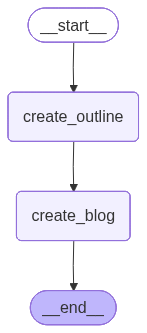

In [14]:
workflow

In [11]:
initial_state={'title':'Rise of AI in india '}

final_state=workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in india ', 'outline': '**Title:** The Rise of AI in India: Opportunities, Challenges, and Future Prospects\n\n**I. Introduction**\n\n* Brief overview of AI and its growing importance globally\n* Importance of India in the AI landscape\n* Thesis statement: India is poised to become a significant player in the AI industry, driven by government initiatives, technological advancements, and growing demand for AI solutions.\n\n**II. Government Initiatives and Support**\n\n* Overview of government initiatives:\n + AI for All (AIFORALL) program\n + National AI Portal\n + AI for India (AIFORINDIA) program\n + Other initiatives and policies\n* Impact of government support on the growth of AI in India\n* Examples of successful AI projects initiated by the government\n\n**III. Technological Advancements**\n\n* Overview of key AI technologies:\n + Machine Learning (ML)\n + Deep Learning (DL)\n + Natural Language Processing (NLP)\n + Computer Vision\n* Indian companies and res

In [12]:
final_state['outline']


'**Title:** The Rise of AI in India: Opportunities, Challenges, and Future Prospects\n\n**I. Introduction**\n\n* Brief overview of AI and its growing importance globally\n* Importance of India in the AI landscape\n* Thesis statement: India is poised to become a significant player in the AI industry, driven by government initiatives, technological advancements, and growing demand for AI solutions.\n\n**II. Government Initiatives and Support**\n\n* Overview of government initiatives:\n + AI for All (AIFORALL) program\n + National AI Portal\n + AI for India (AIFORINDIA) program\n + Other initiatives and policies\n* Impact of government support on the growth of AI in India\n* Examples of successful AI projects initiated by the government\n\n**III. Technological Advancements**\n\n* Overview of key AI technologies:\n + Machine Learning (ML)\n + Deep Learning (DL)\n + Natural Language Processing (NLP)\n + Computer Vision\n* Indian companies and research institutions working on AI technologies

In [13]:
final_state['content']

"**The Rise of AI in India: Opportunities, Challenges, and Future Prospects**\n\n**I. Introduction**\n\nArtificial Intelligence (AI) has become a transformative force globally, revolutionizing industries and transforming the way we live and work. The importance of AI cannot be overstated, as it has the potential to drive economic growth, improve healthcare outcomes, and enhance productivity. India, with its large and growing population, has emerged as a significant player in the AI landscape. The country has made significant strides in AI research and development, and government initiatives, technological advancements, and growing demand for AI solutions have created a fertile ground for AI adoption.\n\nIndia's strategic location, large talent pool, and favorable business environment make it an attractive destination for AI companies and research institutions. The government has launched several initiatives to promote AI adoption, and the country has seen a surge in AI startups and ent